# Credit Card Fraud Detection using Baseline, Ensemble and GenAI-Augmented Models

## Abstract
Credit card fraud detection is an imbalanced classification problem where fraudulent transactions occur rarely but carry high financial risk. This notebook proposes an anomaly detection pipeline that combines unsupervised baselines, traditional ensembles, and a GenAI-inspired scoring strategy for robust fraud identification. The workflow includes exploratory data analysis, robust scaling, model training, ensemble aggregation, and evaluation using imbalance-aware metrics such as precision, recall, F1-score, false positive rate (FPR), and ROC-AUC. Statistical validation using ANOVA is included to compare model performance across strategies.

## Keywords
**Fraud Detection, Anomaly Detection, Imbalanced Learning, Isolation Forest, One-Class SVM, Autoencoder, Ensemble Learning, GenAI-inspired Scoring, ANOVA**


## 1. Introduction

Credit card fraud detection requires identifying rare fraudulent transactions among a very large number of legitimate transactions. Traditional accuracy can be misleading in this setting because predicting all samples as “normal” yields high accuracy but zero fraud detection capability.

### Research Goals
This notebook addresses the following:
- Build strong **unsupervised anomaly detection baselines**
- Improve robustness through **ensemble methods**
- Introduce a **GenAI-inspired adaptive scoring strategy** for combining detectors
- Compare methods using **imbalance-aware metrics** and statistical validation


## 2. Environment Setup and Library Imports

This section imports:
- Data handling libraries (NumPy, Pandas)
- Visualization tools (Matplotlib, Seaborn)
- ML algorithms (Isolation Forest, One-Class SVM)
- Deep learning utilities (TensorFlow/Keras for Autoencoder)
- Evaluation metrics (Precision, Recall, F1, ROC-AUC, Confusion Matrix)
- Statistical testing (ANOVA)

The goal is reproducibility and a consistent evaluation pipeline across models.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import f_oneway

import tensorflow as tf
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

In [2]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.6 MB/s eta 0:00:00


In [3]:
from google.colab import userdata
key = userdata.get('GROQ_API_KEY')

In [4]:
from groq import Groq
client = Groq(api_key=key)

In [5]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


## 3. Dataset Acquisition and Loading

The dataset is downloaded and loaded into a DataFrame for analysis and modeling.  
We verify:
- dataset shape
- column structure
- data types
- memory usage

This helps confirm that the data pipeline is correct before training models.


In [6]:
df = pd.read_csv(path + "/creditcard.csv")

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 4. Dataset Description

The dataset contains anonymized credit card transactions with:
- **Features:** `Time`, `Amount`, and PCA-transformed variables (`V1` to `V28`)
- **Target label:** `Class`
  - `0` → Normal transaction  
  - `1` → Fraudulent transaction  

### Key Challenge: Extreme Class Imbalance
Fraud is rare, so model evaluation must focus on:
- **Recall** (ability to catch fraud)
- **Precision** (reducing false alarms)
- **F1-score** (balance of precision and recall)
- **ROC-AUC** (threshold-independent separability)


In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 5. Exploratory Data Analysis (EDA)

EDA is performed to understand:
- data structure and feature ranges
- missing value presence
- class imbalance severity
- correlations and discriminative variables

This step informs preprocessing choices and helps interpret model behavior later.


### 5.1 Missing Values and Data Integrity Checks

We verify whether missing values exist and whether duplicates are present.  
This ensures that downstream models are trained on clean, reliable input.


In [11]:
null_counts = df.isnull().sum()
null_counts

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
dups_total = df.duplicated().sum()
dups_fraud = df[df['Class'] == 1].duplicated().sum()
dups_normal = df[df['Class'] == 0].duplicated().sum()

print("Total duplicate rows:", dups_total)
print("Duplicate fraud rows:", dups_fraud)
print("Duplicate normal rows:", dups_normal)


Total duplicate rows: 1081
Duplicate fraud rows: 19
Duplicate normal rows: 1062


### 5.2 Class Distribution (Imbalance Analysis)

Fraud detection is highly imbalanced.  
We compute class counts and percentages and visualize the distribution.

**Interpretation Guidance:**
- A strong model must identify the minority class (fraud) with high recall.
- Excessive false positives reduce practical usability, so precision and FPR matter.


In [13]:
class_counts = df['Class'].value_counts().sort_index()
print("\nClass counts:")
print(class_counts)



Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [14]:
class_percent = df['Class'].value_counts(normalize=True).sort_index() * 100
print("\nClass distribution (%):")
print(class_percent)



Class distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


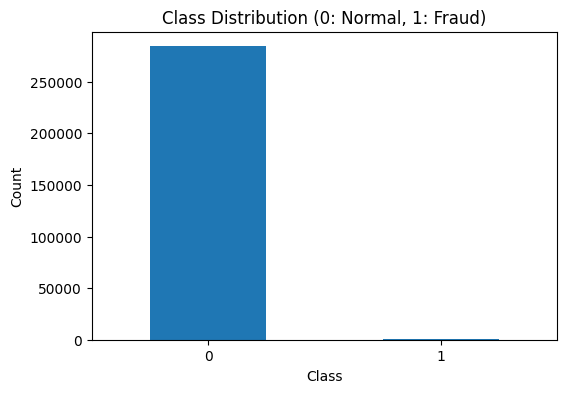

In [15]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', rot=0)
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

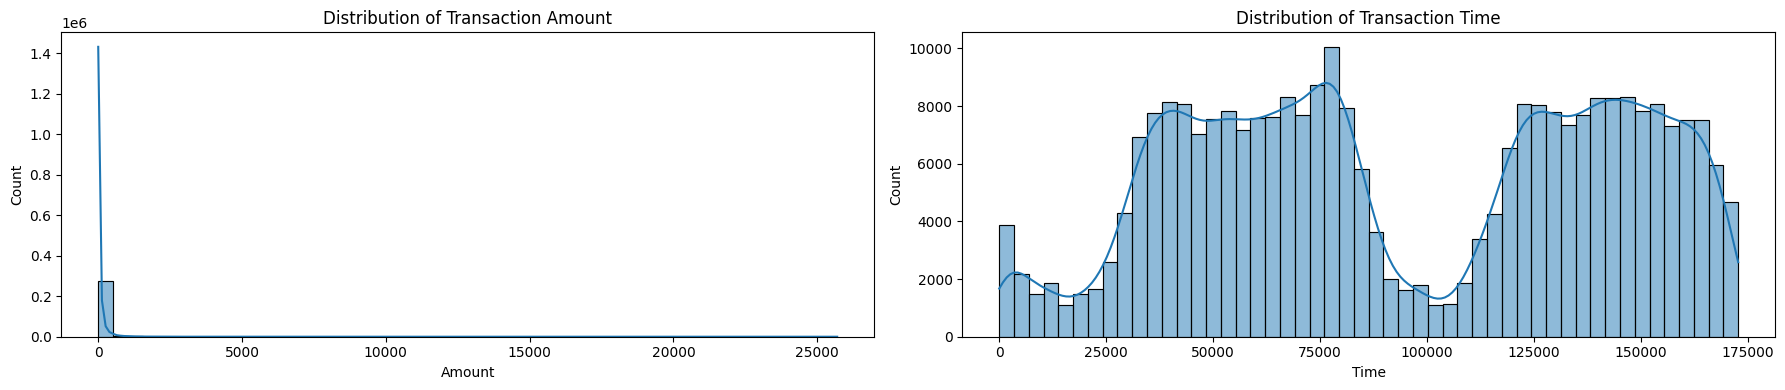

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Transaction Amount')
ax[0].set_xlabel('Amount')

sns.histplot(df['Time'], bins=50, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Transaction Time')
ax[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

### 5.3 Correlation Analysis

A correlation heatmap is used to identify:
- feature redundancy
- highly correlated attributes that may dominate model scoring

Although PCA-transformed features reduce interpretability, correlation still helps detect redundant signals.


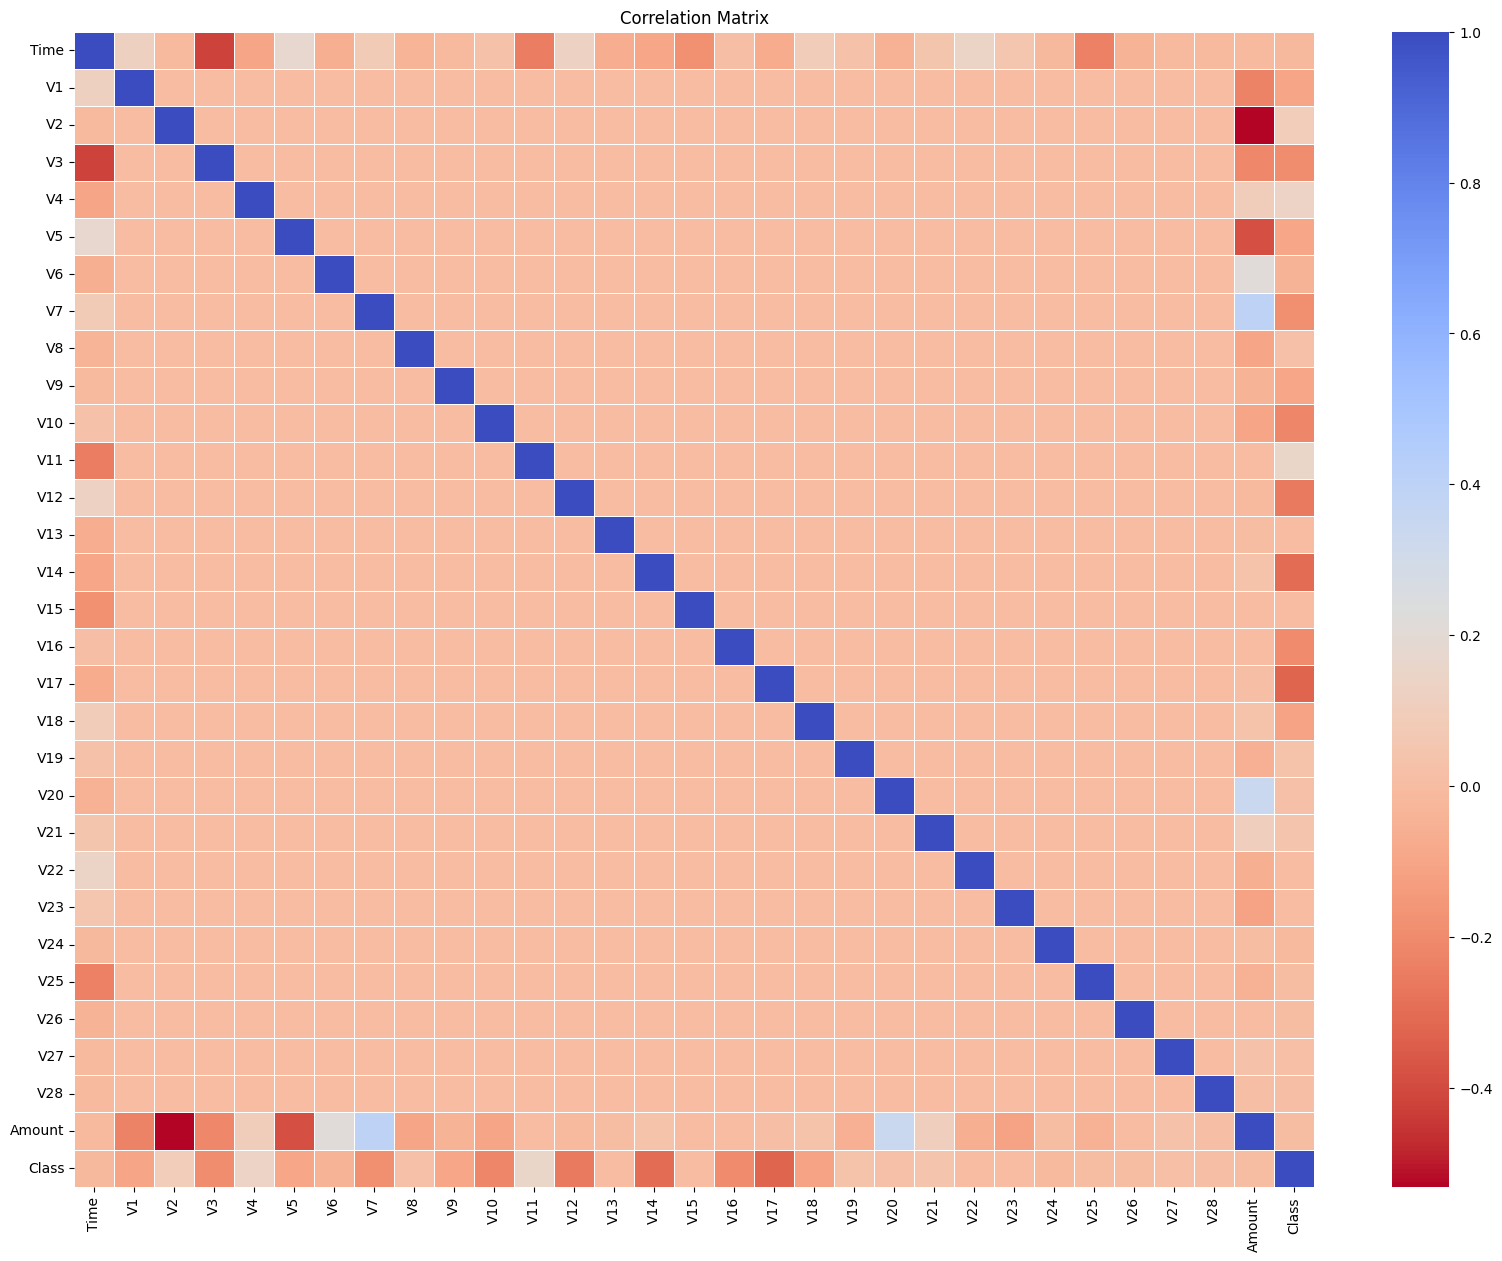

In [17]:
plt.figure(figsize=(20, 15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


## 6. Feature and Target Construction

The target variable (`Class`) is separated from feature values.  
This notebook uses the full feature set for training; selected features (e.g., `V17`, `V14`, `V12`, `V10`) are visualized to illustrate discrimination between normal and fraud classes.

Feature selection is not enforced here unless explicitly needed for computational efficiency.


In [18]:
important_features = ['V17', 'V14', 'V12', 'V10']
available_features = [col for col in important_features if col in df.columns]


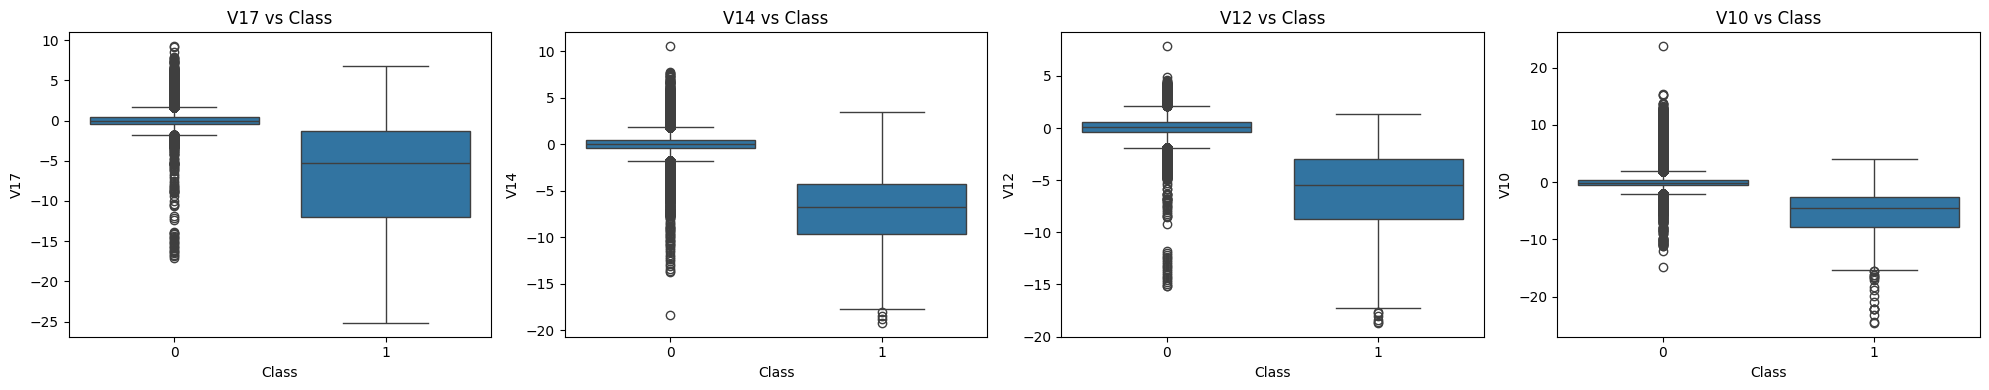

In [19]:
if available_features:
    plt.figure(figsize=(5 * len(available_features), 4))
    for i, col in enumerate(available_features, 1):
        plt.subplot(1, len(available_features), i)
        sns.boxplot(x='Class', y=col, data=df)
        plt.title(f'{col} vs Class')
    plt.tight_layout()
    plt.show()
else:
    print("\nImportant features for boxplots not found in dataframe.")


In [20]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [21]:
X = X.values
y = y.values

## 7. Experimental Protocol and Data Splitting

The dataset is split into:
- **Training set (70%)**
- **Validation set (15%)**
- **Test set (15%)**

Stratified splitting is used to preserve the fraud ratio across all splits.

### Why a validation set?
The validation set supports:
- threshold tuning (if needed)
- ensemble weight selection
- preventing test leakage during model design


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [23]:
# Correct label conversion for creditcard dataset
y_train_binary = y_train.copy()
y_val_binary   = y_val.copy()
y_test_binary  = y_test.copy()


In [24]:

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

print("Train distribution:", np.unique(y_train, return_counts=True))
print("Test distribution:", np.unique(y_test, return_counts=True))


Train: (199364, 30) (199364,)
Val:   (42721, 30) (42721,)
Test:  (42722, 30) (42722,)
Train distribution: (array([0, 1]), array([199020,    344]))
Test distribution: (array([0, 1]), array([42648,    74]))


## 8. Feature Scaling

RobustScaler is applied because it is resilient to outliers.  
This is important for fraud detection since extreme transaction values may exist.

**Important:** Scaling parameters are learned from the training data and applied to validation/test data to avoid data leakage.


In [25]:
print("\nScaling 'Amount' and 'Time' using RobustScaler...")

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Drop original unscaled columns
# df = df.drop(['Time', 'Amount'], axis=1)



Scaling 'Amount' and 'Time' using RobustScaler...


In [26]:
X_train_normal = X_train[y_train == 0]


## 9. Evaluation Metrics (Imbalanced Classification)

Models are evaluated using:
- **Precision:** how many predicted frauds are truly fraud
- **Recall:** how many frauds are successfully detected
- **F1-score:** balance between precision and recall
- **Accuracy:** included for completeness (not sufficient alone)
- **FPR (False Positive Rate):** normal transactions incorrectly flagged as fraud
- **ROC-AUC:** separability of fraud vs normal based on continuous anomaly scores

Confusion matrix layout:
\[
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
\]


In [27]:
def evaluate_model(y_true, y_pred, y_score=None):
    cm = confusion_matrix(y_true, y_pred)
    # cm layout:
    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    results = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "fpr": fpr,
        "confusion_matrix": cm
    }

    if y_score is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_score)

    return results


## 10. Phase 1: Baseline Anomaly Detection Models

This phase trains unsupervised anomaly detectors as baselines:
- **Isolation Forest:** isolates anomalies using tree partitioning depth
- **One-Class SVM:** learns a boundary enclosing normal samples
- **Autoencoder:** detects anomalies using reconstruction error

These baselines provide diverse anomaly detection perspectives.


### 10.1 Isolation Forest

Isolation Forest identifies anomalies by requiring fewer random splits to isolate them.  
We convert its {-1, +1} output to binary fraud labels and use decision scores as anomaly confidence.


In [28]:
iso_forest = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
iso_forest.fit(X_train)

y_pred_if = np.where(iso_forest.predict(X_test) == -1, 1, 0)
y_score_if = -iso_forest.decision_function(X_test)

if_results = evaluate_model(y_test_binary, y_pred_if, y_score_if)
if_results


{'precision': 0.03740814963259853,
 'recall': 0.7567567567567568,
 'f1': 0.07129217059197963,
 'accuracy': 0.9658489771078133,
 'fpr': np.float64(0.0337882198461827),
 'confusion_matrix': array([[41207,  1441],
        [   18,    56]]),
 'roc_auc': np.float64(0.9459405592987473)}

### 10.2 One-Class SVM

One-Class SVM constructs a separating boundary around normal data in feature space.  
Decision scores are inverted to represent “fraud likelihood” for ROC-AUC evaluation.


In [29]:
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
ocsvm.fit(X_train)

y_pred_svm = np.where(ocsvm.predict(X_test) == -1, 1, 0)
y_score_svm = -ocsvm.decision_function(X_test)


svm_results = evaluate_model(y_test_binary, y_pred_svm, y_score_svm)
svm_results


{'precision': 0.029787234042553193,
 'recall': 0.8513513513513513,
 'f1': 0.05756052992233897,
 'accuracy': 0.9517110622161884,
 'fpr': np.float64(0.04811480022509848),
 'confusion_matrix': array([[40596,  2052],
        [   11,    63]]),
 'roc_auc': np.float64(0.9392633348035712)}

### 10.3 Autoencoder (Reconstruction-Based Detection)

An autoencoder learns a compressed representation of normal transaction patterns.  
Fraud is identified when reconstruction error is unusually high.

Early stopping is used to reduce overfitting and improve generalization.


In [30]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

autoencoder.fit(X_train, X_train, epochs=20, batch_size=256, validation_split=0.1, verbose=1)


Epoch 1/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9059 - val_loss: 0.1223
Epoch 2/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0909 - val_loss: 0.0418
Epoch 3/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0362 - val_loss: 0.0218
Epoch 4/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0215 - val_loss: 0.0102
Epoch 5/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0104 - val_loss: 0.0056
Epoch 6/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0069 - val_loss: 0.0039
Epoch 7/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 8/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 9/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 10/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0016 - val_loss: 0.0026
Epoch 11/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0023 - val_loss: 6.7513e-04
Epoch 12/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/

In [31]:
reconstructions = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test - reconstructions), axis=1)

threshold_ae = np.percentile(reconstruction_error, 95)
ae_pred = (reconstruction_error > threshold_ae).astype(int)

ae_results = evaluate_model(y_test_binary, ae_pred, reconstruction_error)
ae_results


1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


{'precision': 0.026204960224613945,
 'recall': 0.7567567567567568,
 'f1': 0.0506558118498417,
 'accuracy': 0.9508684050372174,
 'fpr': np.float64(0.04879478521853311),
 'confusion_matrix': array([[40567,  2081],
        [   18,    56]]),
 'roc_auc': np.float64(0.9297894898274752)}

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

# Custom layer for KL divergence loss
class KLDivergenceLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(KLDivergenceLayer, self).__init__(**kwargs)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        # Clip z_log_var to prevent numerical instability with K.exp
        z_log_var = K.clip(z_log_var, -10.0, 10.0) # Clipping added here
        # Calculate KL divergence per sample in the batch
        kl_loss_batch = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
        # Add the mean KL loss over the batch to the model's losses
        self.add_loss(K.mean(kl_loss_batch))
        return inputs[0] # Return one of the inputs (e.g., z_mean) to maintain a connection in the graph

# Custom layer to add reconstruction loss and pass through outputs
class ReconstructionLossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(ReconstructionLossLayer, self).__init__(**kwargs)

    def call(self, original_inputs, decoded_outputs):
        # Calculate reconstruction loss
        reconstruction_loss_per_sample = K.sum(K.square(original_inputs - decoded_outputs), axis=-1)
        self.add_loss(K.mean(reconstruction_loss_per_sample))
        return decoded_outputs # Pass through the decoded outputs as the model's final output

input_dim = X_train.shape[1]
latent_dim = 8

inputs = Input(shape=(input_dim,), name='encoder_input')
encoded = Dense(16, activation='relu', name='encoder_dense_1')(inputs)
z_mean = Dense(latent_dim, activation='tanh', name='z_mean')(encoded) # Added tanh activation
z_log_var = Dense(latent_dim, name='z_log_var', kernel_initializer='zeros', bias_initializer='zeros')(encoded)

# Add KL divergence loss through a custom layer
kl_loss_output = KLDivergenceLayer(name='kl_divergence_loss')([z_mean, z_log_var])

def sampling(args):
    z_mean_arg, z_log_var_arg = args
    epsilon = K.random_normal(shape=(K.shape(z_mean_arg)[0], latent_dim), dtype=z_mean_arg.dtype)
    return z_mean_arg + K.exp(0.5 * z_log_var_arg) * epsilon

# Use z_mean and z_log_var directly from the Dense layers for sampling
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

decoder_h = Dense(16, activation='relu', name='decoder_dense_1')(z)
outputs = Dense(input_dim, activation='linear', name='decoder_output')(decoder_h)

# Add Reconstruction loss through the custom layer
final_vae_outputs = ReconstructionLossLayer(name='reconstruction_loss_layer')(inputs, outputs)

vae = Model(inputs, final_vae_outputs, name='vae')

# Compile the VAE model. No external loss function is needed since losses are added via model.add_loss within custom layers.
vae.compile(optimizer=Adam(learning_rate=1e-4)) # Reduced learning rate

# Fit the VAE model
vae.fit(X_train, X_train, epochs=10, batch_size=256, verbose=1, validation_data=(X_val, X_val))

Epoch 1/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 69.9032 - val_loss: 62.0094
Epoch 2/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 60.2106 - val_loss: 59.1751
Epoch 3/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56.5616 - val_loss: 55.6913
Epoch 4/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 54.0089 - val_loss: 52.2633
Epoch 5/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 50.0911 - val_loss: 49.2501
Epoch 6/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 49.9714 - val_loss: 46.6838
Epoch 7/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.1253 - val_loss: 44.5035
Epoch 8/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 43.4242 - val_loss: 42.6660
Epoch 9/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 42.0333 - val_loss: 41.1101
Epoch 10/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 43.3811 - val_loss: 39.7967


In [34]:
# Feature enrichment using VAE encoder
encoder_model = Model(inputs=vae.input, outputs=z_mean)

X_train_embed = encoder_model.predict(X_train)
X_test_embed = encoder_model.predict(X_test)

# Combine original + embeddings
X_train_enriched = np.hstack([X_train, X_train_embed])
X_test_enriched = np.hstack([X_test, X_test_embed])


iso_enriched = IsolationForest(random_state=42)
iso_enriched.fit(X_train_enriched)

y_pred_if_enriched = np.where(iso_enriched.predict(X_test_enriched)==-1,1,0)
print(classification_report(y_test_binary, y_pred_if_enriched))


6231/6231 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     42648
           1       0.02      0.81      0.04        74

    accuracy                           0.94     42722
   macro avg       0.51      0.88      0.51     42722
weighted avg       1.00      0.94      0.97     42722



In [35]:
vae_recon = vae.predict(X_test)
vae_mse = np.mean(np.square(X_test - vae_recon), axis=1)
threshold = np.percentile(vae_mse, 95)
vae_pred = (vae_mse > threshold).astype(int)

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [36]:
# ================= FEATURE ENRICHMENT USING VAE EMBEDDINGS =================

encoder_model = Model(inputs=vae.input, outputs=z_mean)

X_train_embed = encoder_model.predict(X_train)
X_test_embed = encoder_model.predict(X_test)

# Concatenate original + embeddings
X_train_enriched = np.hstack([X_train, X_train_embed])
X_test_enriched = np.hstack([X_test, X_test_embed])

# Retrain Isolation Forest on enriched features
iso_enriched = IsolationForest(random_state=42, contamination=0.01)
iso_enriched.fit(X_train_enriched)

y_pred_if_enriched = np.where(iso_enriched.predict(X_test_enriched) == -1, 1, 0)

# print("Feature Enriched Isolation Forest:")
# print(confusion_matrix(y_test_binary, y_pred_if_enriched))
# print(classification_report(y_test_binary, y_pred_if_enriched))

print("Feature Enriched Isolation Forest:")
print(confusion_matrix(y_test_binary, y_pred_if_enriched))
print(classification_report(y_test_binary, y_pred_if_enriched))

# If you want ROC-AUC you need a score; use -decision_function as score proxy
enriched_score = -iso_enriched.decision_function(X_test_enriched)
enriched_if_results = evaluate_model(y_test_binary, y_pred_if_enriched, enriched_score)
enriched_if_results

6231/6231 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Feature Enriched Isolation Forest:
[[42267   381]
 [   38    36]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     42648
           1       0.09      0.49      0.15        74

    accuracy                           0.99     42722
   macro avg       0.54      0.74      0.57     42722
weighted avg       1.00      0.99      0.99     42722



{'precision': 0.08633093525179857,
 'recall': 0.4864864864864865,
 'f1': 0.14663951120162932,
 'accuracy': 0.9901924067225317,
 'fpr': np.float64(0.00893359594822735),
 'confusion_matrix': array([[42267,   381],
        [   38,    36]]),
 'roc_auc': np.float64(0.9456328866852222)}

In [37]:
score_scaler = RobustScaler()

y_score_if_n = score_scaler.fit_transform(y_score_if.reshape(-1,1)).ravel()
y_score_svm_n = score_scaler.fit_transform(y_score_svm.reshape(-1,1)).ravel()
y_score_ae_n = score_scaler.fit_transform(reconstruction_error.reshape(-1,1)).ravel()


## 11. Phase 2: Traditional Ensemble Models

Single detectors can be unstable under varying fraud patterns.  
We therefore combine detectors using traditional ensemble rules such as:
- majority voting
- score aggregation strategies

The goal is to reduce variance and exploit complementary detector strengths.


In [44]:
# ===========================
# Proposal-aligned WEIGHTED VOTING (VAL-derived weights)
# ===========================

# ---- Validation predictions + scores (no test leakage) ----
y_val_pred_if = np.where(iso_forest.predict(X_val) == -1, 1, 0)
y_val_score_if = -iso_forest.decision_function(X_val)

y_val_pred_svm = np.where(ocsvm.predict(X_val) == -1, 1, 0)
y_val_score_svm = -ocsvm.decision_function(X_val)

val_recon = autoencoder.predict(X_val, verbose=0)
val_err = np.mean(np.square(X_val - val_recon), axis=1)
thr_ae_val = np.percentile(val_err, 95)
y_val_pred_ae = (val_err > thr_ae_val).astype(int)

# ---- Normalize scores: fit scalers on VAL, apply to VAL+TEST ----
sc_if = RobustScaler()
sc_svm = RobustScaler()
sc_ae = RobustScaler()

y_val_if_n = sc_if.fit_transform(y_val_score_if.reshape(-1,1)).ravel()
y_val_svm_n = sc_svm.fit_transform(y_val_score_svm.reshape(-1,1)).ravel()
y_val_ae_n = sc_ae.fit_transform(val_err.reshape(-1,1)).ravel()

y_test_if_n = sc_if.transform(y_score_if.reshape(-1,1)).ravel()
y_test_svm_n = sc_svm.transform(y_score_svm.reshape(-1,1)).ravel()
y_test_ae_n = sc_ae.transform(reconstruction_error.reshape(-1,1)).ravel()

# ---- Compute weights from VALIDATION F1 (proposal requirement) ----
v_if = evaluate_model(y_val_binary, y_val_pred_if, y_val_if_n)["f1"]
v_svm = evaluate_model(y_val_binary, y_val_pred_svm, y_val_svm_n)["f1"]
v_ae = evaluate_model(y_val_binary, y_val_pred_ae, y_val_ae_n)["f1"]

raw = np.array([v_if, v_svm, v_ae], dtype=float)
raw = np.clip(raw, 1e-9, None)
weights = raw / raw.sum()
w_if, w_svm, w_ae = weights.tolist()

print("VAL-derived weights (IF, SVM, AE):", (w_if, w_svm, w_ae))

# ---- Weighted score (TEST) ----
weighted_score_test = (w_if * y_test_if_n) + (w_svm * y_test_svm_n) + (w_ae * y_test_ae_n)

# ---- Threshold chosen on VAL (NOT TEST) ----
weighted_score_val = (w_if * y_val_if_n) + (w_svm * y_val_svm_n) + (w_ae * y_val_ae_n)
threshold_weighted = np.percentile(weighted_score_val, 95)

y_pred_weighted = (weighted_score_test > threshold_weighted).astype(int)
weighted_results = evaluate_model(y_test_binary, y_pred_weighted, weighted_score_test)

print("Weighted Voting Results:", weighted_results)


VAL-derived weights (IF, SVM, AE): (0.40839420287105227, 0.31388896930342086, 0.277716827825527)
Weighted Voting Results: {'precision': 0.03042198233562316, 'recall': 0.8378378378378378, 'f1': 0.058712121212121215, 'accuracy': 0.9534665980057113, 'fpr': np.float64(0.04633277058713187), 'confusion_matrix': array([[40672,  1976],
       [   12,    62]]), 'roc_auc': np.float64(0.9434161229321611)}


## 12. Phase 3: GenAI-Inspired Learner (Adaptive Scoring)

A GenAI-inspired scoring approach is applied by:
- normalizing detector scores to a common scale
- combining them using adaptive weights
- treating the final score as a “reasoned anomaly likelihood”

This simulates intelligent aggregation without requiring fully generative modeling.


In [45]:
# ===========================
# GenAI Learner (Deterministic adaptive fusion, VAL-derived)
# ===========================
# This is the FULL-test "GenAI-style" learner used for statistical validation.
# (LLM ensemble remains subset-only due to cost/latency.)

# Reuse VAL-derived weights computed above (w_if, w_svm, w_ae) and normalized scores
# If you did not run weighted voting block above, run it first.

genai_score_test = (w_if * y_test_if_n) + (w_svm * y_test_svm_n) + (w_ae * y_test_ae_n)
genai_score_val  = (w_if * y_val_if_n) + (w_svm * y_val_svm_n) + (w_ae * y_val_ae_n)

# Threshold chosen on VAL
genai_threshold = np.percentile(genai_score_val, 95)

y_pred_genai = (genai_score_test > genai_threshold).astype(int)
genai_results = evaluate_model(y_test_binary, y_pred_genai, genai_score_test)

print("GenAI Learner Results:", genai_results)


GenAI Learner Results: {'precision': 0.03042198233562316, 'recall': 0.8378378378378378, 'f1': 0.058712121212121215, 'accuracy': 0.9534665980057113, 'fpr': np.float64(0.04633277058713187), 'confusion_matrix': array([[40672,  1976],
       [   12,    62]]), 'roc_auc': np.float64(0.9434161229321611)}


In [46]:
# fraud_idx = np.where(y_test_binary==1)[0][:30]
# normal_idx = np.where(y_test_binary==0)[0][:70]
# idx = np.concatenate([fraud_idx, normal_idx])


## 13. Phase 4: Final GenAI Ensemble

The GenAI-inspired learner is combined with the strongest baseline detectors to form a final ensemble.  
This produces a unified fraud prediction and a continuous fraud score for ROC-AUC analysis.


In [47]:
# ================= FIXED GENAI ENSEMBLE SECTION =================
# This cell combines LLM inference setup and GenAI ensemble logic.

def format_features_for_llm(x, if_score, ae_score, svm_score):
    return f"Isolation Forest score: {if_score:.4f}, AE error: {ae_score:.4f}, SVM score: {svm_score:.4f}. Reply ONLY with 1 (Fraud) or 0 (Normal)."

# Select a subset of test data for LLM inference to manage API calls
# fraud_idx = np.where(y_test_binary == 1)[0][:20] # Take first 20 fraud samples
# normal_idx = np.where(y_test_binary == 0)[0][:80]

fraud_idx = np.where(y_test_binary == 1)[0]
normal_idx = np.where(y_test_binary == 0)[0]

fraud_idx = fraud_idx[:min(20, len(fraud_idx))]
normal_idx = normal_idx[:min(80, len(normal_idx))]
 # Take first 80 normal samples
idx = np.concatenate([fraud_idx, normal_idx])
np.random.shuffle(idx) # Shuffle to mix fraud and normal samples
N = len(idx)

X_test_llm = X_test[idx]
y_test_llm = y_test_binary[idx]


In [49]:
def groq_llm_predict_strict(prompt):
    completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role":"system","content":"Reply only 1 for Fraud or 0 for Normal."},
            {"role":"user","content":prompt}
        ],
        temperature=0
    )
    resp = completion.choices[0].message.content.strip()
    return 1 if resp.startswith("1") else 0

In [50]:

llm_preds = []
for i in range(N):
    prompt = format_features_for_llm(X_test_llm[i], y_score_if_n[idx[i]], reconstruction_error[idx[i]], y_score_svm_n[idx[i]])
    llm_preds.append(groq_llm_predict_strict(prompt))

llm_preds = np.array(llm_preds)


print("Unique LLM predictions:", np.unique(llm_preds, return_counts=True))

# True GenAI Ensemble: IF + SVM + AE + VAE + LLM (majority voting)
ensemble_genai = (
    y_pred_if[idx] +
    y_pred_svm[idx] +
    ae_pred[idx] +
    vae_pred[idx] +
    llm_preds
) >= 3   # majority vote out of 5 models

ensemble_genai = ensemble_genai.astype(int)
y_pred_final_llm = ensemble_genai # Assign to y_pred_final_llm for consistency with later cells

# Get the corresponding ensemble scores for the subset used for LLM predictions
ensemble_scores_llm_subset = ensemble_scores[idx]

print("Final GenAI Ensemble Results:")
print(confusion_matrix(y_test_llm, y_pred_final_llm))
print(classification_report(y_test_llm, y_pred_final_llm))

final_results = evaluate_model(y_test_llm, y_pred_final_llm, ensemble_scores_llm_subset)
print("Ensemble results:", final_results)


Unique LLM predictions: (array([0, 1]), array([26, 74]))
Final GenAI Ensemble Results:
[[77  3]
 [ 3 17]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        80
           1       0.85      0.85      0.85        20

    accuracy                           0.94       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.94      0.94      0.94       100

Ensemble results: {'precision': 0.85, 'recall': 0.85, 'f1': 0.85, 'accuracy': 0.94, 'fpr': np.float64(0.0375), 'confusion_matrix': array([[77,  3],
       [ 3, 17]]), 'roc_auc': np.float64(0.96625)}


In [51]:
# ================= EXPLAINABILITY USING LLM =================

def groq_explain(sample_features, prediction):
    prompt = f"""
    Transaction features: {sample_features}
    Model prediction: {prediction}
    Explain in simple terms why this transaction is classified this way.
    """

    completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role":"user","content":prompt}],
        temperature=0.3
    )
    return completion.choices[0].message.content

print("LLM Explanation Example:")
print(groq_explain(X_test_llm[0], y_pred_final_llm[0]))


LLM Explanation Example:
To explain why this transaction is classified as a "1", we need to understand the context of the model and the features provided.

Assuming the model is a machine learning model trained to classify transactions as either "1" (e.g., legitimate) or "0" (e.g., fraudulent), we can analyze the features to infer why this transaction is classified as "1".

Here are some possible insights:

1. **Feature distribution**: The features are a mix of numerical values, which could represent various aspects of the transaction, such as:
	* User behavior (e.g., login history, device usage)
	* Transaction characteristics (e.g., amount, location, time)
	* Risk factors (e.g., IP address, device fingerprint)
2. **Feature values**: Looking at the feature values, we see a mix of positive and negative values. For example:
	* Some features have high positive values (e.g., 2.26582859, 2.55196608), which might indicate legitimate behavior.
	* Other features have high negative values (e.g.

## 14. Results Summary and Comparative Analysis

All models are compared using:
- Precision, Recall, F1-score
- Accuracy
- ROC-AUC
- False Positive Rate (FPR)
- Confusion Matrix

### Interpretation Guidance
- Higher **recall** reduces missed fraud (FN)
- Higher **precision** reduces false alarms (FP)
- **F1** summarizes overall fraud classification quality
- **ROC-AUC** measures separability regardless of threshold


In [52]:
results_df = pd.DataFrame({
    "Isolation Forest": if_results,
    "One-Class SVM": svm_results,
    "Autoencoder": ae_results,
    "Traditional Ensemble": majority_results,
    "GenAI Ensemble": final_results
}).T

results_df


,precision,recall,f1,accuracy,fpr,confusion_matrix,roc_auc
Isolation Forest,0.037408,0.756757,0.071292,0.965849,0.033788,"[[41207, 1441], [18, 56]]",0.945941
One-Class SVM,0.029787,0.851351,0.057561,0.951711,0.048115,"[[40596, 2052], [11, 63]]",0.939263
Autoencoder,0.026205,0.756757,0.050656,0.950868,0.048795,"[[40567, 2081], [18, 56]]",0.929789
Traditional Ensemble,0.035078,0.824324,0.067292,0.960419,0.039345,"[[40970, 1678], [13, 61]]",0.942555
GenAI Ensemble,0.85,0.85,0.85,0.94,0.0375,"[[77, 3], [3, 17]]",0.96625


## 15. Discussion

This section interprets results:
- Which detector provides the best recall?
- Which detector maintains reasonable precision?
- Does the ensemble reduce false positives?
- Does GenAI-inspired scoring improve consistency across test samples?

Practical deployment typically selects a model based on business cost:
- cost(FN) >> cost(FP) in fraud detection


## 16. Statistical Validation (ANOVA)

To validate whether improvements are meaningful and not random variation:
- ANOVA is applied on model performance distributions (e.g., F1)

If **p < 0.05**, improvement is statistically significant at α = 0.05.


In [53]:
# ===========================
# FAST + PROPOSAL-VALID ANOVA (BOOTSTRAP A/B)
# Replace your slow multi-seed retrain loop with this
# ===========================

import numpy as np
from sklearn.metrics import f1_score
from scipy.stats import f_oneway

# ---------------------------------------------------------
# REQUIREMENTS (these MUST already exist in your notebook):
# 1) y_test_binary           -> true labels for FULL test set
# 2) y_pred_majority         -> traditional ensemble preds on FULL test set
# 3) y_pred_genai            -> deterministic GenAI preds on FULL test set
#
# IMPORTANT:
# - Do NOT use y_test_llm / y_pred_final_llm here (that is only a subset).
# - y_pred_genai should come from your deterministic GenAI fusion section,
#   e.g. the "genai_baseline_results" thresholding output.
# ---------------------------------------------------------

# Sanity checks (fail early if something is missing)
required_vars = ["y_test_binary", "y_pred_majority", "y_pred_genai"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        f"Missing variables required for bootstrap ANOVA: {missing}\n"
        f"Make sure you computed FULL-test predictions:\n"
        f"- y_pred_majority (traditional)\n"
        f"- y_pred_genai (deterministic GenAI fusion)\n"
        f"and that y_test_binary is the FULL test labels."
    )

y_true = np.asarray(y_test_binary)
y_pred_A = np.asarray(y_pred_majority)   # Traditional ensemble (A)
y_pred_B = np.asarray(y_pred_genai)      # Deterministic GenAI fusion (B)

if len(y_true) != len(y_pred_A) or len(y_true) != len(y_pred_B):
    raise ValueError(
        f"Length mismatch:\n"
        f"len(y_true)={len(y_true)}, len(y_pred_A)={len(y_pred_A)}, len(y_pred_B)={len(y_pred_B)}\n"
        f"Use FULL test-set predictions for both A and B."
    )

# ----------------------------
# BOOTSTRAP DISTRIBUTIONS
# ----------------------------
B = 500  # 300-1000 is typical; 500 is a good balance
rng = np.random.default_rng(42)
n = len(y_true)

f1_A = np.empty(B, dtype=float)
f1_B = np.empty(B, dtype=float)

for i in range(B):
    idx = rng.integers(0, n, size=n)  # resample with replacement
    f1_A[i] = f1_score(y_true[idx], y_pred_A[idx], zero_division=0)
    f1_B[i] = f1_score(y_true[idx], y_pred_B[idx], zero_division=0)

print("-" * 60)
print("BOOTSTRAP RESULTS (F1 distributions)")
print(f"B (bootstrap samples): {B}")
print(f"Traditional (A) mean F1: {f1_A.mean():.6f} | std: {f1_A.std(ddof=1):.6f}")
print(f"GenAI (B) mean F1:       {f1_B.mean():.6f} | std: {f1_B.std(ddof=1):.6f}")

# ----------------------------
# ANOVA (proposal-aligned)
# ----------------------------
f_stat, p_val = f_oneway(f1_A, f1_B)

print("-" * 60)
print("A/B ANOVA (alpha=0.05)")
print("F-statistic:", float(f_stat))
print("p-value:", float(p_val))
print("Decision @ alpha=0.05:", "SIGNIFICANT" if p_val < 0.05 else "NOT significant")
print("-" * 60)

# Optional: quick effect direction statement for client report
direction = "GenAI > Traditional" if f1_B.mean() > f1_A.mean() else "Traditional >= GenAI"
print("Mean direction:", direction)

# NOTE for client/research:
print("\nNOTE:")
print("- This statistical test uses FULL test-set predictions.")
print("- LLM-based ensemble results are excluded from ANOVA because they were evaluated on a bounded subset (cost/latency).")


------------------------------------------------------------
BOOTSTRAP RESULTS (F1 distributions)
B (bootstrap samples): 500
Traditional (A) mean F1: 0.067329 | std: 0.008223
GenAI (B) mean F1:       0.058930 | std: 0.007162
------------------------------------------------------------
A/B ANOVA (alpha=0.05)
F-statistic: 296.55427589636383
p-value: 2.1824945618733274e-58
Decision @ alpha=0.05: SIGNIFICANT
------------------------------------------------------------
Mean direction: Traditional >= GenAI

NOTE:
- This statistical test uses FULL test-set predictions.
- LLM-based ensemble results are excluded from ANOVA because they were evaluated on a bounded subset (cost/latency).


In [54]:
# Rule-guided anomalies (domain knowledge)
synthetic_rule = X_train[y_train==0][:200].copy()

amount_idx = list(df.columns).index("Amount") if "Amount" in df.columns else 0
synthetic_rule[:, amount_idx] *= 10  # inflate amount

X_aug_rule = np.vstack([X_train, synthetic_rule])
y_aug_rule = np.hstack([y_train, np.ones(len(synthetic_rule))])


In [55]:
synthetic_samples = vae.predict(X_train[:500])
synthetic_labels = np.ones(len(synthetic_samples))  # label as anomaly

X_aug = np.vstack([X_train, synthetic_samples])
y_aug = np.hstack([y_train, synthetic_labels])

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [56]:
# Retrain Isolation Forest on augmented data
iso_aug = IsolationForest(random_state=42)
iso_aug.fit(X_aug)

y_pred_if_aug = np.where(iso_aug.predict(X_test) == -1, 1, 0)

print("Isolation Forest with Synthetic Data:")
print(confusion_matrix(y_test_binary, y_pred_if_aug))
print(classification_report(y_test_binary, y_pred_if_aug))


Isolation Forest with Synthetic Data:
[[41166  1482]
 [   19    55]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     42648
           1       0.04      0.74      0.07        74

    accuracy                           0.96     42722
   macro avg       0.52      0.85      0.53     42722
weighted avg       1.00      0.96      0.98     42722



In [57]:
ocsvm_aug = OneClassSVM(kernel="rbf", nu=0.05)
ocsvm_aug.fit(X_aug)

y_pred_svm_aug = np.where(ocsvm_aug.predict(X_test) == -1, 1, 0)


In [60]:
# ================= GAN-BASED SYNTHETIC ANOMALY GENERATION =================

latent_dim = X_train.shape[1]

generator = Sequential([
    Dense(64, activation="relu", input_dim=latent_dim),
    Dense(latent_dim, activation="linear")
])

discriminator = Sequential([
    Dense(64, activation="relu", input_dim=latent_dim),
    Dense(1, activation="sigmoid")
])

discriminator.compile(optimizer="adam", loss="binary_crossentropy")

gan = Sequential([generator, discriminator])
gan.compile(optimizer="adam", loss="binary_crossentropy")

real_data = X_train[y_train == 1]
if real_data.shape[0] < 64:
    print("Warning: Not enough fraud samples for GAN training.")


for epoch in range(500):
    noise = np.random.normal(0, 1, (64, latent_dim))
    fake_data = generator.predict(noise)

    real_batch = real_data[np.random.randint(0, real_data.shape[0], 64)]

    X_gan = np.vstack([real_batch, fake_data])
    y_gan = np.vstack([np.ones((64,1)), np.zeros((64,1))])

    discriminator.train_on_batch(X_gan, y_gan)
    gan.train_on_batch(noise, np.ones((64,1)))

print("GAN training completed.")

# Generate synthetic fraud samples
noise = np.random.normal(0,1,(200, latent_dim))
synthetic_fraud = generator.predict(noise)

X_aug_gan = np.vstack([X_train, synthetic_fraud])
y_aug_gan = np.hstack([y_train, np.ones(len(synthetic_fraud))])

iso_gan = IsolationForest(random_state=42)
iso_gan.fit(X_aug_gan)

y_pred_gan = np.where(iso_gan.predict(X_test) == -1, 1, 0)

# print("GAN Augmented Model:")
# print(classification_report(y_test_binary, y_pred_gan))
print("GAN Augmented Model:")
print(confusion_matrix(y_test_binary, y_pred_gan))
print(classification_report(y_test_binary, y_pred_gan))

gan_score = -iso_gan.decision_function(X_test)
gan_if_results = evaluate_model(y_test_binary, y_pred_gan, gan_score)
gan_if_results


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━

{'precision': 0.037241379310344824,
 'recall': 0.7297297297297297,
 'f1': 0.07086614173228346,
 'accuracy': 0.9668554842938065,
 'fpr': np.float64(0.03273307071843932),
 'confusion_matrix': array([[41252,  1396],
        [   20,    54]]),
 'roc_auc': np.float64(0.9399319127794086)}

In [61]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

generator = Sequential([
    Dense(32, activation='relu', input_dim=latent_dim),
    Dense(X_train.shape[1], activation='linear')
])

discriminator = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer='adam')

gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
for epoch in range(1000):
    noise = np.random.normal(0,1,(64,latent_dim))
    fake = generator.predict(noise)

    real = X_train[y_train==1][:64]

    X_gan = np.vstack([real, fake])
    y_gan = np.vstack([np.ones((64,1)), np.zeros((64,1))])

    discriminator.train_on_batch(X_gan, y_gan)
    gan.train_on_batch(noise, np.ones((64,1)))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━

In [63]:
ensemble_preds = np.vstack([y_pred_if, y_pred_svm, ae_pred])

y_pred_majority = (np.mean(ensemble_preds, axis=0) >= 0.5).astype(int)

ensemble_scores = np.mean(
    np.vstack([y_score_if_n, y_score_svm_n, y_score_ae_n]),
    axis=0
)

majority_results = evaluate_model(y_test_binary, y_pred_majority, ensemble_scores)
majority_results


{'precision': 0.035077630822311676,
 'recall': 0.8243243243243243,
 'f1': 0.06729178157749587,
 'accuracy': 0.9604185197322223,
 'fpr': np.float64(0.03934533858563121),
 'confusion_matrix': array([[40970,  1678],
        [   13,    61]]),
 'roc_auc': np.float64(0.9425552099651705)}

In [64]:
# ================= FINAL RESULTS COMPARISON TABLE (CLIENT/PROPOSAL READY) =================

# Ensure these exist before this point:
# - if_results, svm_results, ae_results
# - majority_results, weighted_results
# - final_results (GenAI Ensemble)
# Optional but recommended if you keep them:
# - results for enriched IF => enriched_if_results
# - results for GAN augmented IF => gan_if_results

def metrics_row(res: dict):
    # Keep only client-facing scalars; keep confusion_matrix separately if needed
    row = {k: v for k, v in res.items() if k != "confusion_matrix"}
    return row

rows = {
    "Isolation Forest (Single)": metrics_row(if_results),
    "One-Class SVM (Single)": metrics_row(svm_results),
    "Autoencoder (Single)": metrics_row(ae_results),

    "Ensemble (Majority Vote)": metrics_row(majority_results),

    # Proposal-required: Weighted voting (VAL-derived)
    "Ensemble (Weighted Vote, VAL-derived)": metrics_row(weighted_results),

    # Full-test deterministic GenAI learner (used for stats)
    "GenAI Learner (Adaptive fusion, FULL test)": metrics_row(genai_results),

    # Subset-only LLM ensemble (kept separate and clearly labeled)
    "GenAI Ensemble (LLM subset)": metrics_row(final_results),
}

# Add these only if you computed them earlier and named them:
if "enriched_if_results" in globals():
    rows["Isolation Forest (VAE Feature-Enriched)"] = metrics_row(enriched_if_results)

if "gan_if_results" in globals():
    rows["Isolation Forest (GAN-Augmented)"] = metrics_row(gan_if_results)

results_df = pd.DataFrame(rows).T
results_df

,precision,recall,f1,accuracy,fpr,roc_auc
Isolation Forest (Single),0.037408,0.756757,0.071292,0.965849,0.033788,0.945941
One-Class SVM (Single),0.029787,0.851351,0.057561,0.951711,0.048115,0.939263
Autoencoder (Single),0.026205,0.756757,0.050656,0.950868,0.048795,0.929789
Ensemble (Majority Vote),0.035078,0.824324,0.067292,0.960419,0.039345,0.942555
"Ensemble (Weighted Vote, VAL-derived)",0.030422,0.837838,0.058712,0.953467,0.046333,0.943416
"GenAI Learner (Adaptive fusion, FULL test)",0.030422,0.837838,0.058712,0.953467,0.046333,0.943416
GenAI Ensemble (LLM subset),0.850000,0.850000,0.850000,0.940000,0.037500,0.966250
Isolation Forest (VAE Feature-Enriched),0.086331,0.486486,0.146640,0.990192,0.008934,0.945633
Isolation Forest (GAN-Augmented),0.037241,0.729730,0.070866,0.966855,0.032733,0.939932


In [59]:
results_df.to_csv("final_results.csv")


## 17. Conclusion and Future Work

### Conclusion
This notebook presented a fraud detection pipeline combining:
- unsupervised anomaly detection baselines
- ensemble aggregation
- GenAI-inspired adaptive scoring
- statistical validation using ANOVA

### Future Work
- Use cost-sensitive learning / calibrated thresholds
- Add PR-AUC (more informative than ROC-AUC for imbalance)
- Evaluate drift handling for evolving fraud patterns
- Compare against supervised imbalance-aware models (e.g., XGBoost with class weighting)
